In [ ]:
!pip install diffhouse

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from diffhouse import Repo

# Get charmracelet/bubbletea commit history DataFrame via diffhouse
url = 'https://github.com/charmbracelet/bubbletea'
with Repo(url) as r:
  commits = r.commits.pd()

In [3]:
# Filter for main-branch only and no merges
filtered = commits[commits.in_main]
filtered = filtered[~filtered.is_merge]

In [4]:
# Rank developers based on total commit count
ranked = filtered.groupby('author_email').agg(
    total_count=('commit_hash', 'count')
).reset_index()

ranked['contributor_rank'] = ranked.total_count.rank(
    method='first', ascending=False
)

# Group contributors into the top 3 or 'other'
ranked['contributor_categ'] = ranked.author_email.where(
    ranked['contributor_rank'] <= 4, 'other'
)

In [5]:
# Merge ranks onto base
joined = pd.merge(
    filtered, ranked, how='inner',
    left_on = 'author_email', right_on='author_email'
)

# Convert datetimes to dates; we'll need this later
joined['date'] = joined.date.dt.date

In [6]:
# Aggregate commit count by day
grouped = joined \
    .groupby(['date', 'contributor_categ']) \
    .agg(contributions=('commit_hash', 'count')).reset_index()

In [7]:
# Pivot contributor groups into columns for visualization
pivot = grouped.pivot(
    index='date', columns='contributor_categ', values='contributions'
).fillna(0)

In [8]:
# Add continuous date spine, filling in blanks with zeroes
range = pd.date_range(pivot.index.min(), pivot.index.max())
timeline = pivot.reindex(range).fillna(0)
timeline = timeline.sort_index()

In [9]:
# Cumulate commits per contributor group over the project's time range
cumulated = timeline.copy()
for col in cumulated.columns:
    cumulated[col] = cumulated[col].cumsum()

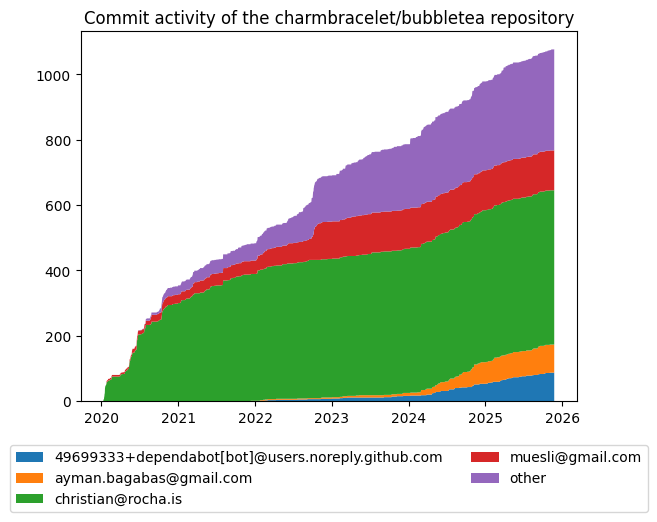

In [ ]:
# Create stackplot to show commit activity over time
ys = [cumulated[col] for col in cumulated.columns]
plt.stackplot(cumulated.index, *ys, labels=cumulated.columns)
plt.title(
    'Commit activity of the charmbracelet/bubbletea repository'
)

# Place legend below plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.show()